# Reduce one raster position: is a lattice, or an a/b splitting, resolvable here?

Determines the lattice at ONE position of a raster scan of a single crystal or a few domains
-- ingest, index every domain, audit completeness and honesty, and (if the gates allow it)
refine an a/b splitting with a bootstrap error bar. Built entirely on `midas_defect`/`midas_hkls`
package functions documented in `manuals/defect/` and `manuals/solve-cell/` -- this notebook
is a thin, annotated driver, not new science.

**This is the single-point half.** For a whole raster (one point or all of them, sharded for a
large scan), see `06_raster_lattice_batch.ipynb`. Read that notebook's closing cell before
trusting an a/b splitting from THIS one alone: a single position's gates cannot rule out a
common radial-systematic artifact across domains -- only a raster-wide check can (see the note
in Step 2's output when it applies).

**No material default anywhere.** Six `midas_defect.rows` functions default to one DAC sample's
cell (`manuals/solve-cell/PACKAGE_NOTES.md` §2); this notebook and the functions it calls
require yours explicitly, every time.


## Step 0 — CONFIG

Set your material (no default), your geometry, and how to load one position's frames. With no
`LOADER` set, this notebook runs on a synthetic position with a known planted answer
(`midas_defect.synthetic.synthetic_position_frames`) -- built from the SAME geometry primitives
(`ewald_crossing_omegas`, `qsample_to_qlab`, `qlab_to_pixel`) the real ingest chain and
`find_domains` consume, and pushed through the real ingest chain too (mask, background,
blob-finding, powder separation) -- so every cell below shows real output with no download.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import midas_defect as dx
from midas_defect.geometry import Geometry
from midas_defect.raster import reduce_one_position

# ---- the only lines you change ------------------------------------------------------
A, C = 4.0, 10.0                  # YOUR material's cell (fictional example values here)
SPACE_GROUP_NUMBER = 123          # YOUR space group (P4/mmm here -- purely illustrative)
SIGMA_RTN = (0.02, 0.02, 0.02)    # YOUR measured (radial, transverse, normal) residual budget,
                                   # in 1/A -- see manuals/solve-cell/phase-3-refine.md. The
                                   # package default (0.0071, 0.0145, 0.0094) is one DAC
                                   # sample's, not yours.
GEOM = None                        # a midas_defect.geometry.Geometry -- e.g.
                                   # Geometry.from_paramstest("parameters_final.txt") -- or
                                   # None for the synthetic fallback below
LOADER = None                      # LOADER(p) -> (n_frames, n_rows, n_cols) raw frame stack
                                   # for raster position p, or None for the synthetic fallback
POINT = 0                          # which position to reduce

# --- pointing LOADER at REAL frames: the one non-obvious step (validated on a real 2604
# raster position, 2026-09-12). A raw stack usually has dead/shutter-ramp frames at the ends
# (partial-exposure frames from the shutter opening/closing) that must come OUT before this
# function sees them, and GEOM.omega_first_deg must be remapped to whichever raw frame ends up
# first -- reduce_one_position maps frame index -> omega directly, with no dead-frame logic of
# its own. Sketch (fill in your own file naming):
#
#   from midas_defect.ingest import live_frames
#   RAW_OMEGA0, DOMEGA = -19.5, 1.0             # your own scan's raw omega program
#   def LOADER(p):
#       raw = np.stack([tifffile.imread(my_path(p, k)) for k in range(N_RAW_FRAMES)])
#       live, _ = live_frames(raw)                          # drops dead/shutter-ramp frames
#       first = int(np.flatnonzero(live)[0])
#       GEOM.omega_first_deg = RAW_OMEGA0 + DOMEGA * first   # remap to the first LIVE frame
#       return raw[live]
#
# `live_frames` decides per POSITION, so a real raster's positions can end up with different
# frame counts -- fine here (05 reduces one point), but `06_raster_lattice_batch.ipynb`'s
# `reduce_raster_block` takes ONE shared GEOM for the whole raster: check that every position
# you batch drops the same number of leading/trailing frames before assuming one GEOM covers
# all of them (it did for five real 2604 positions checked this way; it need not for yours).
# ---------------------------------------------------------------------------------------

if GEOM is None:
    GEOM = Geometry(lsd_um=120_000.0, bcy_px=384.0, bcz_px=384.0, px_um=172.0,
                    wavelength_A=0.4246, n_pix_y=768, n_pix_z=768,
                    omega_first_deg=-19.5, omega_step_deg=1.0, n_frames=40,
                    label="synthetic example")
    print("No GEOM set: using a synthetic example geometry.")

if LOADER is None:
    from scipy.spatial.transform import Rotation
    from midas_defect.synthetic import synthetic_position_frames
    B_TRUTH = 3.9   # the synthetic fallback's own planted b -- real data has no such thing
    U_TRUTH = Rotation.from_euler("zyx", [15.0, 25.0, -8.0], degrees=True).as_matrix()

    def LOADER(p, _seed=[0]):
        frames, truth = synthetic_position_frames(
            [U_TRUTH], a=A, b=B_TRUTH, c=C, space_group_number=SPACE_GROUP_NUMBER, geom=GEOM,
            hmax=8, kmax=8, lmax=14, seed=p)
        LOADER.truth = truth
        return frames
    print(f"No LOADER set: using a synthetic position with a known answer "
         f"(a={A}, b={B_TRUTH}, c={C}, split={100*(A-B_TRUTH)/B_TRUTH:.3g} %).")

frames = LOADER(POINT)
print(f"point {POINT}: frames {frames.shape}, {frames.dtype}")


No GEOM set: using a synthetic example geometry.
No LOADER set: using a synthetic position with a known answer (a=4.0, b=3.9, c=10.0, split=2.56 %).


point 0: frames (40, 768, 768), float32


## Step 1 — Reduce: ingest, index, audit, refine

`reduce_one_position` runs the whole documented chain in order (`manuals/defect/phase-1-ingest.md`,
`phase-2-index.md`; `manuals/solve-cell/phase-3-refine.md`):

1. **ingest** (mask, background, 3-D blob-finding, powder separation) -- `manuals/defect/phase-1-ingest.md`;
2. an **ω-sign check** (does `find_domains` explain more spots under +ω or −ω?);
3. **`find_domains`**: every crystal domain at this position, row-seeded first, then pair-seeded;
4. per domain: **completeness** (INDEXED/MISSED/MASKED/ABSENT), **honesty** (`decoy_test`,
   `feature_in_raw`), and the **a/b gate chain** (`ab_separable` → `partner_multiplicity` →
   `index_asymmetry` → `shear_separable`);
5. for every domain that passes the gate chain: `refine_cell_joint` with a bootstrap error bar,
   and `split_with_error`.

`res.quotable` distills all of this into one flag -- but read `res.notes` for WHY, not just the
answer. Nothing here overrides a failed gate.


In [2]:
res = reduce_one_position(frames, GEOM, a=A, c=C, space_group_number=SPACE_GROUP_NUMBER,
                          sigma_rtn=SIGMA_RTN, point=POINT, n_bootstrap=300)
print(res.summary())


position 0: 328 spots, omega sign +1 (omega +1: 322 spots explained, omega -1: 0 spots explained)
1 domain(s) found
  domain 0: completeness {'INDEXED': 321, 'MISSED': 6, 'MASKED': 0, 'ABSENT': 0}; honesty informative; feature-in-raw in_raw; ab gate: {'n_k_gt_h': 24, 'n_h_gt_k': 252, 'ratio': 0.09523809523809523, 'sigma_ratio': 0.425292454415503}
  domain 0: targeted recovery 4/4 of 6 missed sites (excess 9.8 sigma over the same-ring null)
a/b split: 2.61 % +/- 0.0173 % (z=1.5e+02)
quotable: True
note: domain 0: index_asymmetry ratio 0.0952 is far from 1 (measured 5x on the 2604 raster was the signature of a radial-systematic artifact, not a real splitting). A SINGLE position cannot rule this out -- 'a common sign across domains is physically impossible' only becomes checkable with several positions/domains; see the raster-wide check.


## Step 2 — Look at the frames: where are the claimed reflections?

The max-intensity projection over all frames, with every domain's CLAIMED spots marked. If a
domain's spots do not sit on real, visible features here, something upstream is wrong no matter
what the numbers below say -- this is the same discipline as DFXM's B4 ("does the map deserve
trust? look at the curves"): read the picture before the summary.


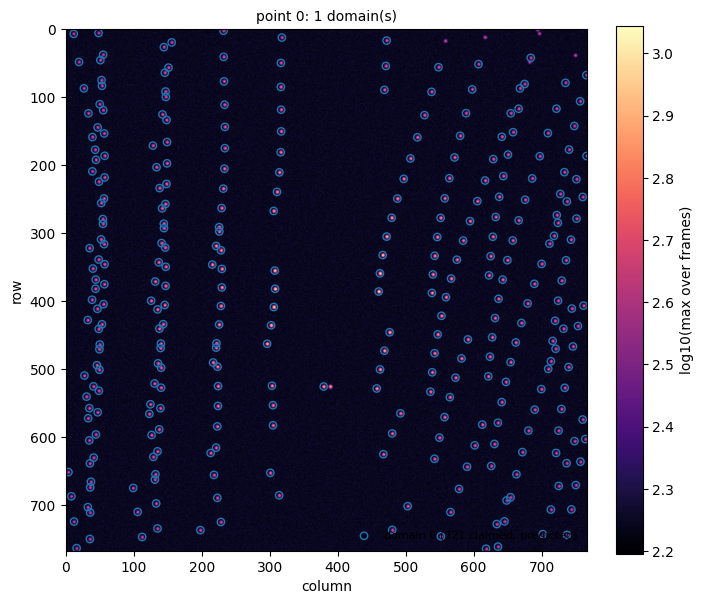

In [3]:
from midas_defect.raster import predict_reflections

colors = plt.cm.tab10(np.linspace(0, 1, max(len(res.domains.domains), 1)))
fig, ax = plt.subplots(figsize=(7, 6.2))
im = ax.imshow(np.log10(np.clip(frames.max(axis=0), 1, None)), cmap="magma")
plt.colorbar(im, ax=ax, fraction=0.046, label="log10(max over frames)")
for i, dom in enumerate(res.domains.domains):
    # predict THIS domain's own claimed hkl back onto the detector, from its own fit -- the
    # same call `reduce_one_position` used for the completeness audit.
    pr, pc, pw, phkl, _kept = predict_reflections(dom.U, dom.lat.B, dom.hkl, GEOM,
                                                  res.omega_sign.chosen_sign)
    ax.scatter(pc, pr, s=28, facecolors="none", edgecolors=[colors[i]],
              label=f"domain {i} ({len(pr)} claimed, predicted)")
ax.set_title(f"point {POINT}: {len(res.domains.domains)} domain(s)", fontsize=10)
ax.set_xlabel("column"); ax.set_ylabel("row")
if res.domains.domains:
    ax.legend(fontsize=8, frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

if not res.domains.domains:
    print("No domains found at this position -- nothing to overlay. See res.notes.")


## Step 3 — Completeness, honesty, and the a/b gate chain, per domain

**Completeness** (INDEXED/MISSED/MASKED/ABSENT): MISSED should be 0 or small -- a predicted
reflection with a real spot nearby that the solver did not assign is a sign something is off.

**Honesty**: `decoy_test` asks whether a deliberately WRONG cell (a few percent off) also
explains this domain's reflections about as well -- if so, passing means nothing.
`feature_in_raw` asks whether the brightest claimed reflection is a real feature in the RAW
frames, not something background subtraction created.

**The a/b gate chain**, in the required order (`manuals/solve-cell/phase-3-refine.md`):
`ab_separable` (rank ≥ 2, necessary not sufficient) → `partner_multiplicity` (a pair on
≤ 1 spot on one side is one blob-finding decision from nothing) → `index_asymmetry`
(a design skewed toward one axis biases the fitted split, with a consistent SIGN across
domains as the signature) → `shear_separable`. A domain only reaches `refine_cell_joint` if
it passes every stage.


In [4]:
for i, (aud, dec, fr, gate) in enumerate(zip(res.completeness, res.decoy,
                                             res.feature_in_raw, res.ab_gates)):
    print(f"--- domain {i} ---")
    print("completeness:", aud.counts)
    print("honesty (decoy_test):", dec["verdict"],
         f"(real {dec['real']:.0f} vs threshold {dec['threshold']:.0f}; "
         f"decoys passing: {dec['decoys_passing'] or 'none'})")
    print("feature in raw frames:", fr["verdict"])
    print("a/b gate:", gate.get("stage") or "passed every stage", "--", gate.get("reason"))
    print()

if res.notes:
    print("NOTES:")
    for n in res.notes:
        print(" -", n)


--- domain 0 ---
completeness: {'INDEXED': 321, 'MISSED': 6, 'MASKED': 0, 'ABSENT': 0}
honesty (decoy_test): informative (real 321 vs threshold 304; decoys passing: none)
feature in raw frames: in_raw
a/b gate: index_asymmetry -- {'n_k_gt_h': 24, 'n_h_gt_k': 252, 'ratio': 0.09523809523809523, 'sigma_ratio': 0.425292454415503}

NOTES:
 - domain 0: index_asymmetry ratio 0.0952 is far from 1 (measured 5x on the 2604 raster was the signature of a radial-systematic artifact, not a real splitting). A SINGLE position cannot rule this out -- 'a common sign across domains is physically impossible' only becomes checkable with several positions/domains; see the raster-wide check.


## Step 4 — The refined cell, if one was possible

`split_with_error` returns `(delta_percent, sigma_percent, z)`. `sigma` is NaN when the
symmetry being fitted forces a = b (nothing was measured, it was imposed) -- that is a
different thing from "no domain passed the gate chain" (`res.refined_cell is None`).


In [5]:
if res.refined_cell is not None:
    a_fit, b_fit, c_fit, alpha, beta, gamma = res.refined_cell
    print(f"refined cell: a={a_fit:.5f}  b={b_fit:.5f}  c={c_fit:.5f}  "
         f"(alpha={alpha:.3f} beta={beta:.3f} gamma={gamma:.3f} deg)")
    delta, sigma, z = res.split_pct
    print(f"a/b split: {delta:.3g} % +/- {sigma:.3g} % (z = {z:.3g})")
    if not np.isfinite(sigma):
        print("sigma is NaN: a and b are equal by the fitted symmetry -- nothing was measured.")
else:
    print("No domain passed the a/b gate chain at this position: no cell was jointly refined.")
print()
print("QUOTABLE:", res.quotable)


refined cell: a=3.89939  b=4.00255  c=9.99968  (alpha=90.000 beta=90.000 gamma=90.000 deg)
a/b split: 2.61 % +/- 0.0173 % (z = 151)

QUOTABLE: True


## What one position can and cannot tell you

- **One position, one gauge.** "a" and "b" are an arbitrary label per domain (a 4-fold or
  mirror symmetry can swap them) -- never compare the SIGN of a split across domains or
  positions without checking the axis convention first.
- **`quotable=True` here means the documented per-position gates passed, not that the number is
  final.** A radial-systematic error can pass every gate above and still manufacture a splitting
  with a consistent sign across domains -- that signature is only visible ACROSS several
  domains/positions. Run `06_raster_lattice_batch.ipynb`'s raster-wide check before quoting
  anything from this notebook alone.
- **Geometry is fixed, not fitted here.** `reduce_one_position` does not self-calibrate; if you
  do not trust the seed geometry, run `midas_defect.selfcal.selfcalibrate_from_crystals`
  separately and inspect it (it has no convergence guarantee).
- **This position's cell is not pooled with any other.** Refining several domains or positions
  JOINTLY against one shared cell is a further, separate analysis
  (`manuals/solve-cell/phase-3-refine.md`), deliberately not automated here.
